In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Experiment 2: Effect of Width

In this experiment, I will study how changing the width of a VGG network affects its performance on the CIFAR-10 classification task.

The depth of the network will be kept fixed at **three VGG blocks**. Each block contains two 3×3 convolutional layers followed by ReLU activations and a 2×2 max-pooling layer.

The only thing I will change is the **number of channels in each block**. I will compare a narrow, base, and wide version of the same three-block architecture.

### Width Configurations

| Model | Block 1 | Block 2 | Block 3 |
|---|---:|---:|---:|
| VGG3-Narrow | 32 | 64 | 128 |
| VGG3-Base | 64 | 128 | 256 |
| VGG3-Wide | 96 | 192 | 384 |

All other training conditions will remain the same across the three models. This includes the dataset, batch size, optimizer, learning rate, momentum, loss function, number of epochs, data augmentation, and weight initialization.

The purpose of this experiment is to see whether giving the network more or fewer channels changes how well it learns and generalizes to unseen data.

In [1]:
cd /kaggle/working

/kaggle/working


In [2]:
!git clone https://github.com/davidmba819/cnn-architecture-study.git /kaggle/working/cnn-architecture-study

fatal: destination path '/kaggle/working/cnn-architecture-study' already exists and is not an empty directory.


In [3]:
%cd /kaggle/working/cnn-architecture-study

/kaggle/working/cnn-architecture-study


In [4]:
!ls

cnn_utils.py  data  notebooks  __pycache__  README.md


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

print("PyTorch:", torch.__version__)
print("Torchvision:", __import__("torchvision").__version__)

PyTorch: 2.10.0+cu128
Torchvision: 0.25.0+cu128


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [7]:

from torchvision import datasets

DATA_DIR = "/kaggle/working/data"

train_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=None
)

test_dataset = datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=False,
    transform=None
)

print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Training samples: 50000
Test samples: 10000


In [8]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
class VGG(nn.Module):

    def __init__(self, channels):
        super().__init__()

        blocks = []
        in_channels = 3

        for out_channels in channels:
            blocks.append(
                VGGBlock(
                    in_channels,
                    out_channels
                )
            )

            in_channels = out_channels

        self.blocks = nn.Sequential(*blocks)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_channels, 10)
        )

        self._initialize_classifier()

    def _initialize_classifier(self):
        linear_layer = self.classifier[2]

        nn.init.xavier_normal_(linear_layer.weight)
        nn.init.zeros_(linear_layer.bias)

    def forward(self, x):
        x = self.blocks(x)
        x = self.classifier(x)

        return x

In [10]:
vgg3_narrow = VGG(
    channels=[32, 64, 128]
)

vgg3_base = VGG(
    channels=[64, 128, 256]
)

vgg3_wide = VGG(
    channels=[96, 192, 384]
)

In [11]:
print("VGG3-Narrow")
print(vgg3_narrow)

print("\nVGG3-Base")
print(vgg3_base)

print("\nVGG3-Wide")
print(vgg3_wide)

VGG3-Narrow
VGG(
  (blocks): Sequential(
    (0): VGGBlock(
      (net): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): VGGBlock(
      (net): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): VGGBlock(
      (net): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU()
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU()
        (4): MaxPool2d(kern

In [12]:
import cnn_utils

train_transform, eval_transform = cnn_utils.create_transforms()

In [13]:
train_data, val_data = cnn_utils.prepare_datasets(
    train_dataset,
    val_ratio=0.2,
    seed=42
)

In [14]:
train_loader, val_loader, test_loader = cnn_utils.create_dataloaders(
    train_data,
    val_data,
    test_dataset,
    train_transform,
    eval_transform,
    batch_size=64,
    num_workers=2
)

In [15]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([64, 3, 32, 32])
Labels: torch.Size([64])


## Experiment 2.1: VGG3-Narrow

The first model in the width experiment is the VGG3-Narrow model.

The network has three VGG blocks, with two convolutional layers in each block. The number of channels is kept relatively small:

- Block 1: 32 channels
- Block 2: 64 channels
- Block 3: 128 channels

The model therefore has six convolutional layers in total.

The architecture is:

Input → VGG Block (32) → VGG Block (64) → VGG Block (128) → Adaptive Average Pooling → Linear Layer

This model will serve as the narrow version in the width experiment. The training setup will remain the same as the other width configurations so that the main difference between the models is the number of channels.

I will train the model for 20 epochs and record the training loss, validation loss, training accuracy, and validation accuracy. After training, the model will be evaluated on the untouched CIFAR-10 test set.

In [16]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    vgg3_narrow.parameters(),
    lr=0.01,
    momentum=0.9
)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
vgg3_narrow, history_vgg3_narrow = cnn_utils.train_model(
    model=vgg3_narrow,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.2990 | Train Acc: 0.5320 | Val Loss: 1.2439 | Val Acc: 0.5587
Epoch [2/20] Train Loss: 1.1344 | Train Acc: 0.5952 | Val Loss: 1.0540 | Val Acc: 0.6238
Epoch [3/20] Train Loss: 1.0068 | Train Acc: 0.6422 | Val Loss: 0.9845 | Val Acc: 0.6501
Epoch [4/20] Train Loss: 0.9207 | Train Acc: 0.6759 | Val Loss: 0.9306 | Val Acc: 0.6625
Epoch [5/20] Train Loss: 0.8404 | Train Acc: 0.7047 | Val Loss: 0.8099 | Val Acc: 0.7186
Epoch [6/20] Train Loss: 0.7752 | Train Acc: 0.7288 | Val Loss: 0.8196 | Val Acc: 0.7163
Epoch [7/20] Train Loss: 0.7089 | Train Acc: 0.7497 | Val Loss: 0.7331 | Val Acc: 0.7415
Epoch [8/20] Train Loss: 0.6575 | Train Acc: 0.7726 | Val Loss: 0.7026 | Val Acc: 0.7544
Epoch [9/20] Train Loss: 0.6066 | Train Acc: 0.7873 | Val Loss: 0.6951 | Val Acc: 0.7547
Epoch [10/20] Train Loss: 0.5670 | Train Acc: 0.8027 | Val Loss: 0.6319 | Val Acc: 0.7783
Epoch [11/20] Train Loss: 0.5178 | Train Acc: 0.8203 | Val Loss: 0.6706 | Val Acc: 0.7696
Epoch [12/20] Train

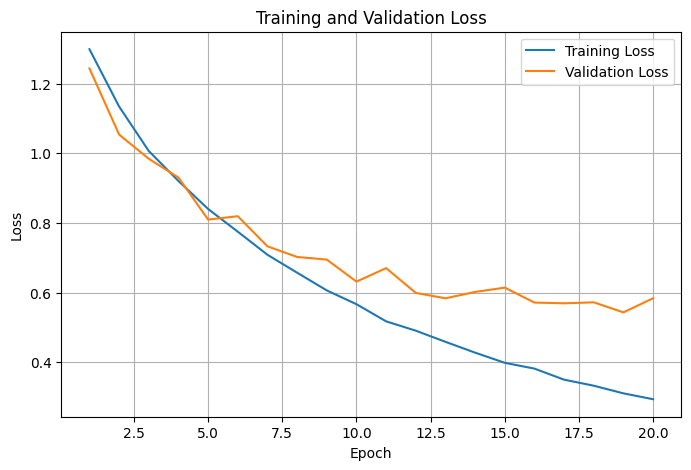

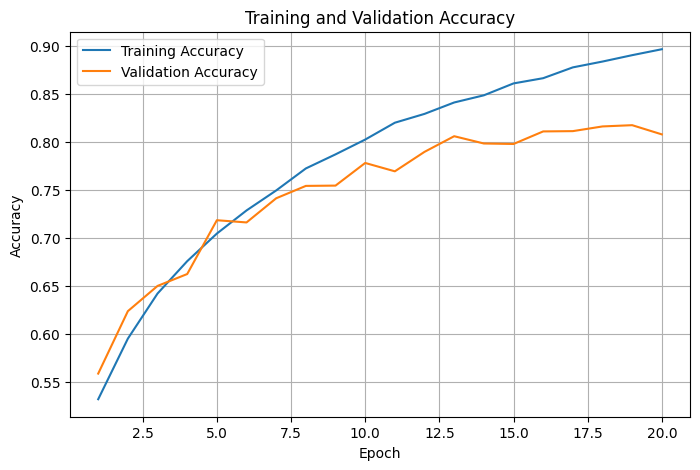

In [27]:
cnn_utils.plot_history(history_vgg3_narrow)

In [28]:
test_loss, test_accuracy = cnn_utils.test_model(
    vgg3_narrow,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.5935
Test Accuracy: 0.8131
Test loss: 0.5935
Test accuracy: 81.31%


## VGG3-Narrow Results

VGG3-Narrow was trained for 20 epochs using the same training settings used throughout the width experiment. The model uses three VGG blocks with **32, 64, and 128 channels** respectively.

### Training Results

The model continued to improve throughout training.

- Final training loss: **0.2942**
- Final validation loss: **0.5842**
- Final training accuracy: **89.69%**
- Final validation accuracy: **80.81%**

The training loss decreased steadily throughout the experiment, while the training accuracy increased to 89.69%.

The validation loss decreased during training but started to fluctuate in the later epochs. Validation accuracy also improved more slowly toward the end, reaching 80.81%.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.5935**
- Test accuracy: **81.31%**

The test accuracy was slightly higher than the final validation accuracy.

### Observation

VGG3-Narrow was able to learn the CIFAR-10 classification task with a relatively small number of channels. The model reached 89.69% training accuracy and 81.31% test accuracy.

The difference between training and validation accuracy at the end of training suggests some overfitting, although the model continued to improve on the training data throughout the experiment.

These results will be used as the reference point for comparison with **VGG3-Base** and **VGG3-Wide**.

## Experiment 2.2: VGG3-Base

The second model in the width experiment is VGG3-Base.

The network still contains three VGG blocks and six convolutional layers, but the number of channels is increased to 64, 128, and 256 in the three blocks.

This model represents the base width configuration and will be compared with the narrower and wider versions.

The training conditions remain unchanged from VGG3-Narrow so that the effect of increasing the number of channels can be observed clearly.

In [29]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    vgg3_base.parameters(),
    lr=0.01,
    momentum=0.9
)

In [30]:
history_vgg3_base = cnn_utils.train_model(
    model=vgg3_base,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.9141 | Train Acc: 0.2653 | Val Loss: 1.6956 | Val Acc: 0.3339
Epoch [2/20] Train Loss: 1.4916 | Train Acc: 0.4432 | Val Loss: 1.3936 | Val Acc: 0.4940
Epoch [3/20] Train Loss: 1.2470 | Train Acc: 0.5480 | Val Loss: 1.1805 | Val Acc: 0.5741
Epoch [4/20] Train Loss: 1.0746 | Train Acc: 0.6135 | Val Loss: 1.0058 | Val Acc: 0.6447
Epoch [5/20] Train Loss: 0.9481 | Train Acc: 0.6642 | Val Loss: 0.9104 | Val Acc: 0.6749
Epoch [6/20] Train Loss: 0.8505 | Train Acc: 0.6994 | Val Loss: 0.8402 | Val Acc: 0.7031
Epoch [7/20] Train Loss: 0.7684 | Train Acc: 0.7324 | Val Loss: 0.7549 | Val Acc: 0.7365
Epoch [8/20] Train Loss: 0.6800 | Train Acc: 0.7628 | Val Loss: 0.6957 | Val Acc: 0.7549
Epoch [9/20] Train Loss: 0.6211 | Train Acc: 0.7821 | Val Loss: 0.7151 | Val Acc: 0.7502
Epoch [10/20] Train Loss: 0.5636 | Train Acc: 0.8030 | Val Loss: 0.5934 | Val Acc: 0.7942
Epoch [11/20] Train Loss: 0.5098 | Train Acc: 0.8239 | Val Loss: 0.6108 | Val Acc: 0.7876
Epoch [12/20] Train

In [32]:
vgg3_base, history_vgg3_base = history_vgg3_base

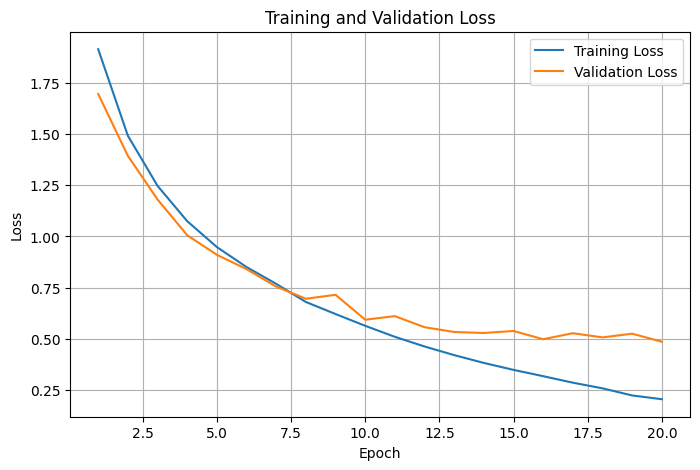

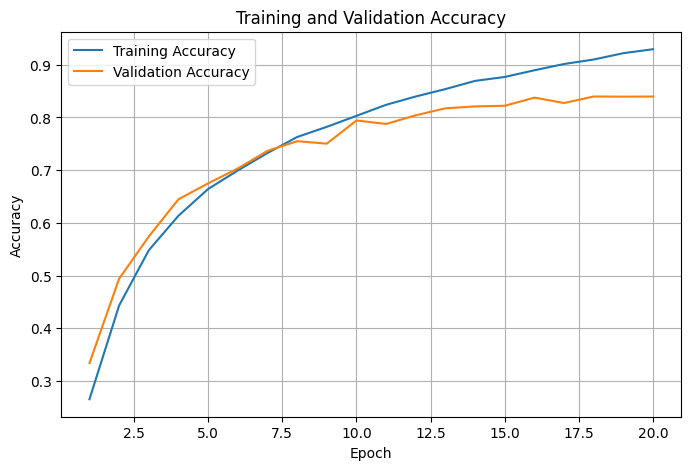

In [33]:
cnn_utils.plot_history(history_vgg3_base)

In [34]:
test_loss, test_accuracy = cnn_utils.test_model(
    vgg3_base,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.5019
Test Accuracy: 0.8406
Test loss: 0.5019
Test accuracy: 84.06%


## VGG3-Base Results

VGG3-Base was trained for 20 epochs using the same training conditions as VGG3-Narrow. The model has three VGG blocks with **64, 128, and 256 channels** respectively.

### Training Results

The model continued to improve throughout the training period.

- Final training loss: **0.2051**
- Final validation loss: **0.4860**
- Final training accuracy: **92.94%**
- Final validation accuracy: **83.96%**

The training loss decreased steadily, while the training accuracy increased to 92.94%. The validation loss also decreased overall, although it fluctuated slightly during the later epochs.

The gap between training and validation accuracy became more noticeable toward the end of training, showing some overfitting. However, the validation accuracy continued to improve and reached 83.96%.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.5019**
- Test accuracy: **84.06%**

The test accuracy was very close to the final validation accuracy.

### Observation

Compared with VGG3-Narrow, increasing the number of channels improved the test accuracy from **81.31% to 84.06%**.

The VGG3-Base model also achieved a higher training accuracy of 92.94%. However, the main result of interest for this experiment is how the increase in width affected performance on unseen data.

These results will be compared with **VGG3-Wide** to determine whether increasing the width further continues to improve generalization.

## Experiment 2.3: VGG3-Wide

The final model in the width experiment is VGG3-Wide.

The network still has three VGG blocks and six convolutional layers, but the number of channels is increased to 96, 192, and 384 in the three blocks.

This is the widest configuration in this experiment. The training conditions remain exactly the same as VGG3-Narrow and VGG3-Base.

The purpose is to see whether increasing the width further improves the model's ability to learn and generalize to unseen data.

In [35]:
vgg3_wide = VGG(
    channels=[96, 192, 384]
)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    vgg3_wide.parameters(),
    lr=0.01,
    momentum=0.9
)


In [36]:
vgg3_wide, history_vgg3_wide = cnn_utils.train_model(
    model=vgg3_wide,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.9162 | Train Acc: 0.2639 | Val Loss: 1.6302 | Val Acc: 0.3785
Epoch [2/20] Train Loss: 1.4734 | Train Acc: 0.4556 | Val Loss: 1.3228 | Val Acc: 0.5226
Epoch [3/20] Train Loss: 1.2045 | Train Acc: 0.5634 | Val Loss: 1.0653 | Val Acc: 0.6223
Epoch [4/20] Train Loss: 1.0304 | Train Acc: 0.6331 | Val Loss: 0.9877 | Val Acc: 0.6560
Epoch [5/20] Train Loss: 0.9156 | Train Acc: 0.6774 | Val Loss: 0.8522 | Val Acc: 0.6987
Epoch [6/20] Train Loss: 0.8126 | Train Acc: 0.7159 | Val Loss: 0.8101 | Val Acc: 0.7197
Epoch [7/20] Train Loss: 0.7185 | Train Acc: 0.7478 | Val Loss: 0.8109 | Val Acc: 0.7202
Epoch [8/20] Train Loss: 0.6441 | Train Acc: 0.7773 | Val Loss: 0.6309 | Val Acc: 0.7805
Epoch [9/20] Train Loss: 0.5739 | Train Acc: 0.8027 | Val Loss: 0.6008 | Val Acc: 0.7905
Epoch [10/20] Train Loss: 0.5246 | Train Acc: 0.8181 | Val Loss: 0.6224 | Val Acc: 0.7850
Epoch [11/20] Train Loss: 0.4703 | Train Acc: 0.8366 | Val Loss: 0.5510 | Val Acc: 0.8093
Epoch [12/20] Train

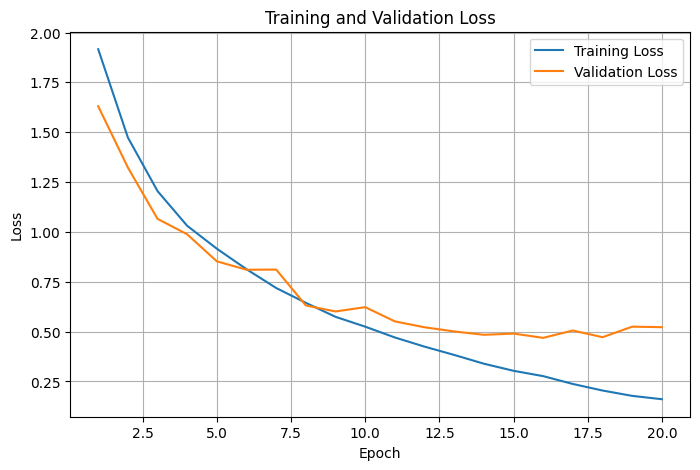

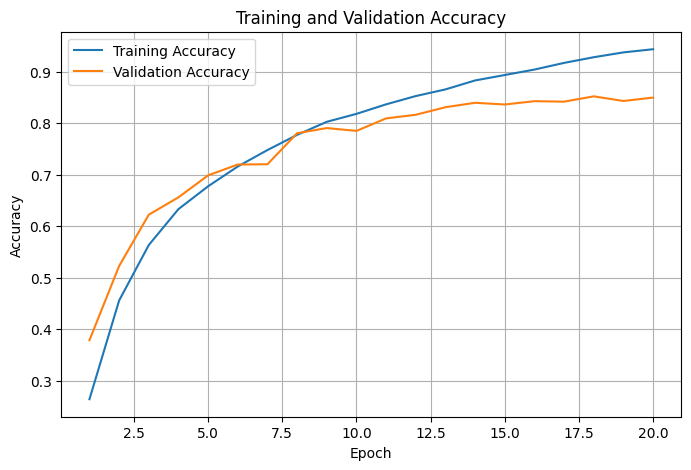

In [37]:
cnn_utils.plot_history(history_vgg3_wide)

In [41]:
test_loss, test_accuracy = cnn_utils.test_model(
    vgg3_wide,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.5546
Test Accuracy: 0.8464
Test loss: 0.5546
Test accuracy: 84.64%


## VGG3-Wide Results

VGG3-Wide was trained for 20 epochs using the same training conditions as VGG3-Narrow and VGG3-Base. The model uses three VGG blocks with **96, 192, and 384 channels** respectively.

### Training Results

The model continued to improve throughout the training period.

- Final training loss: **0.1606**
- Final validation loss: **0.5220**
- Final training accuracy: **94.36%**
- Final validation accuracy: **84.97%**

The training loss decreased steadily and the training accuracy increased to 94.36%. The validation loss also decreased overall, although it fluctuated during the later epochs. Validation accuracy continued to improve and reached 84.97%.

There is a noticeable gap between training and validation accuracy toward the end of training, indicating some overfitting.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.5546**
- Test accuracy: **84.64%**

The test accuracy was slightly lower than the final validation accuracy.

### Observation

VGG3-Wide achieved the highest training accuracy among the three width configurations. Its test accuracy was **84.64%**, compared with **81.31%** for VGG3-Narrow and **84.06%** for VGG3-Base.

The improvement from the Base model to the Wide model was small, despite the increase in the number of channels. The results will be compared across all three models to examine how increasing width affected the model's generalization.

# Experiment 3: Effect of Batch Normalization

In this experiment, I will study how adding Batch Normalization affects the performance of a VGG network on the CIFAR-10 classification task.

The network depth and width will be kept fixed at the VGG3-Base configuration:

- Block 1: 64 channels
- Block 2: 128 channels
- Block 3: 256 channels

The baseline model will use the standard VGG block:

Conv 3×3 → ReLU  
Conv 3×3 → ReLU  
MaxPool 2×2

The Batch Normalization model will use:

Conv 3×3 → BatchNorm → ReLU  
Conv 3×3 → BatchNorm → ReLU  
MaxPool 2×2

The only architectural difference between the two models is the addition of Batch Normalization layers.

All other conditions will remain the same, including the dataset, data augmentation, batch size, optimizer, learning rate, momentum, loss function, weight initialization, and number of training epochs.

The purpose of this experiment is to observe how Batch Normalization changes the training behavior and generalization of the VGG3-Base architecture.

In [18]:
class VGGBlockBN(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2,
                stride=2
            )
        )

        self._initialize_weights()

    def _initialize_weights(self):

        for layer in self.modules():

            if isinstance(layer, nn.Conv2d):

                nn.init.kaiming_normal_(
                    layer.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

In [19]:
class VGG_BN(nn.Module):

    def __init__(self, channels):
        super().__init__()

        blocks = []
        in_channels = 3

        for out_channels in channels:
            blocks.append(
                VGGBlockBN(in_channels, out_channels)
            )
            in_channels = out_channels

        self.blocks = nn.Sequential(*blocks)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_channels, 10)
        )

        self._initialize_classifier()

    def _initialize_classifier(self):

        linear_layer = self.classifier[2]

        nn.init.xavier_normal_(linear_layer.weight)
        nn.init.zeros_(linear_layer.bias)

    def forward(self, x):

        x = self.blocks(x)
        x = self.classifier(x)

        return x

In [20]:
model = VGG_BN([64, 128, 256])

In [22]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

In [24]:
model, history_model = cnn_utils.train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.3173 | Train Acc: 0.5248 | Val Loss: 1.1192 | Val Acc: 0.6079
Epoch [2/20] Train Loss: 0.9147 | Train Acc: 0.6782 | Val Loss: 0.9620 | Val Acc: 0.6656
Epoch [3/20] Train Loss: 0.7479 | Train Acc: 0.7395 | Val Loss: 0.8046 | Val Acc: 0.7137
Epoch [4/20] Train Loss: 0.6364 | Train Acc: 0.7797 | Val Loss: 0.7261 | Val Acc: 0.7410
Epoch [5/20] Train Loss: 0.5582 | Train Acc: 0.8070 | Val Loss: 0.6174 | Val Acc: 0.7849
Epoch [6/20] Train Loss: 0.4988 | Train Acc: 0.8273 | Val Loss: 0.6663 | Val Acc: 0.7652
Epoch [7/20] Train Loss: 0.4486 | Train Acc: 0.8451 | Val Loss: 0.7022 | Val Acc: 0.7639
Epoch [8/20] Train Loss: 0.4018 | Train Acc: 0.8617 | Val Loss: 0.5319 | Val Acc: 0.8171
Epoch [9/20] Train Loss: 0.3621 | Train Acc: 0.8753 | Val Loss: 0.5116 | Val Acc: 0.8258
Epoch [10/20] Train Loss: 0.3261 | Train Acc: 0.8883 | Val Loss: 0.4925 | Val Acc: 0.8361
Epoch [11/20] Train Loss: 0.2932 | Train Acc: 0.8987 | Val Loss: 0.5486 | Val Acc: 0.8172
Epoch [12/20] Train

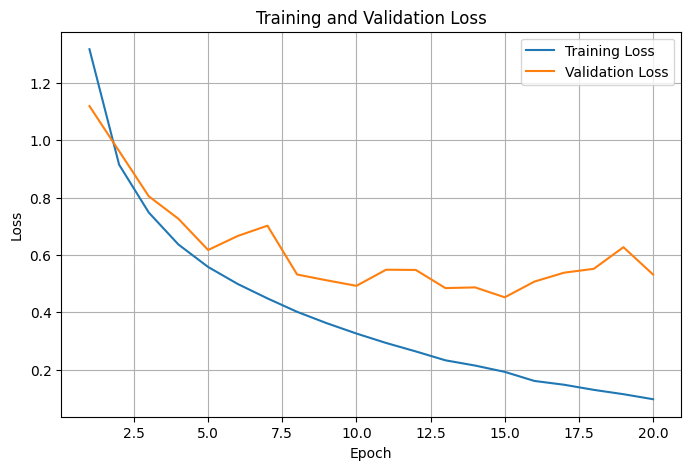

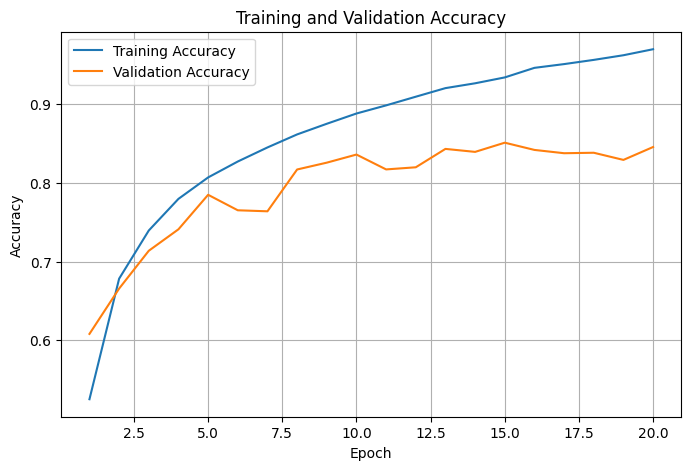

In [25]:
cnn_utils.plot_history(history_model)

In [26]:
test_loss, test_accuracy = cnn_utils.test_model(
    model,
    test_loader,
    loss_function,
    device
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

Test Loss: 0.5834
Test Accuracy: 0.8293
Test loss: 0.5834
Test accuracy: 82.93%


## VGG3-BN Results

VGG3-BN was trained for 20 epochs using the same training conditions as VGG3-Base. The model uses three VGG blocks with **64, 128, and 256 channels** respectively, with Batch Normalization added after each convolution and before the ReLU activation.

### Training Results

The model continued to improve on the training data throughout the training period.

- Final training loss: **0.0971**
- Final validation loss: **0.5318**
- Final training accuracy: **97.01%**
- Final validation accuracy: **84.57%**

The training loss decreased steadily and the training accuracy increased to 97.01%. The validation accuracy improved substantially during the early part of training but fluctuated during the later epochs.

The difference between training and validation accuracy became large toward the end of training, indicating overfitting.

### Test Set Results

The model was evaluated on the untouched CIFAR-10 test set after training.

- Test loss: **0.5834**
- Test accuracy: **82.93%**

### Observation

Compared with the VGG3-Base model, adding Batch Normalization increased the final training accuracy from **92.94% to 97.01%** and the final validation accuracy from **83.96% to 84.57%**.

However, the VGG3-BN model achieved a test accuracy of **82.93%**, compared with **84.06%** for VGG3-Base.

Therefore, in this experiment, the addition of Batch Normalization did not produce a higher test accuracy under the fixed training conditions used.

The results also show that the VGG3-BN model fit the training data more strongly, while the gap between training and validation accuracy became larger toward the end of training.